In [6]:
from scipy import stats
from sklearn import ensemble
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

csv_path = os.path.join(path, os.listdir(path)[0])

# load dataset 
df = pd.read_csv(csv_path)

# dimensions of your dataframe
print(df.shape)

(1000, 8)


In [9]:
# brief description of your numerical attributes
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
# count combinations of values
df.value_counts()

gender  race/ethnicity  parental level of education  lunch         test preparation course  math score  reading score  writing score
male    group E         some high school             standard      none                     94          88             78               1
female  group A         associate's degree           free/reduced  none                     37          57             56               1
                                                                                            41          51             48               1
                                                                                            65          85             76               1
                                                     standard      completed                55          65             62               1
                                                                                                                                       ..
                        high school    

In [13]:
# or counts on a single attribute
df.gender.value_counts()

gender
female    518
male      482
Name: count, dtype: int64

In [14]:
# do we have null values?
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
# now some visualisations. Try different ones!

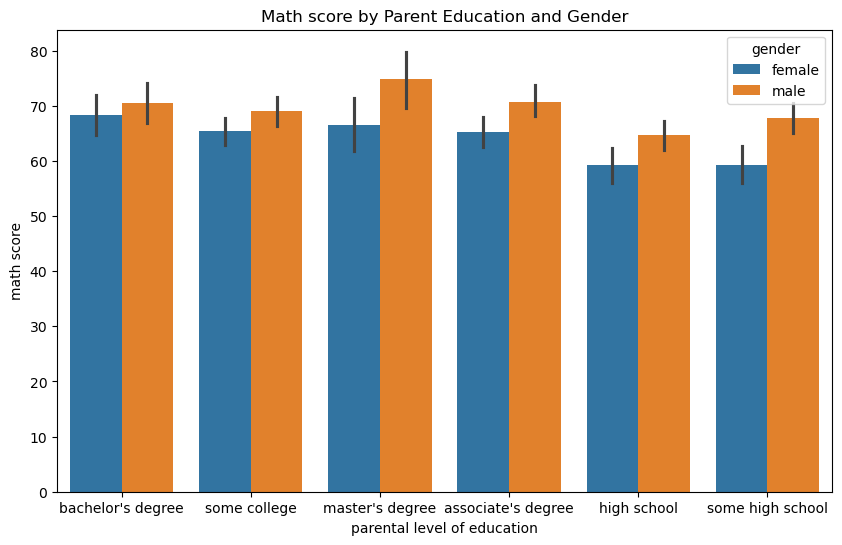

In [23]:
# histogram

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='parental level of education', y='math score', hue='gender')
plt.title('Math score by Parent Education and Gender')
plt.show()

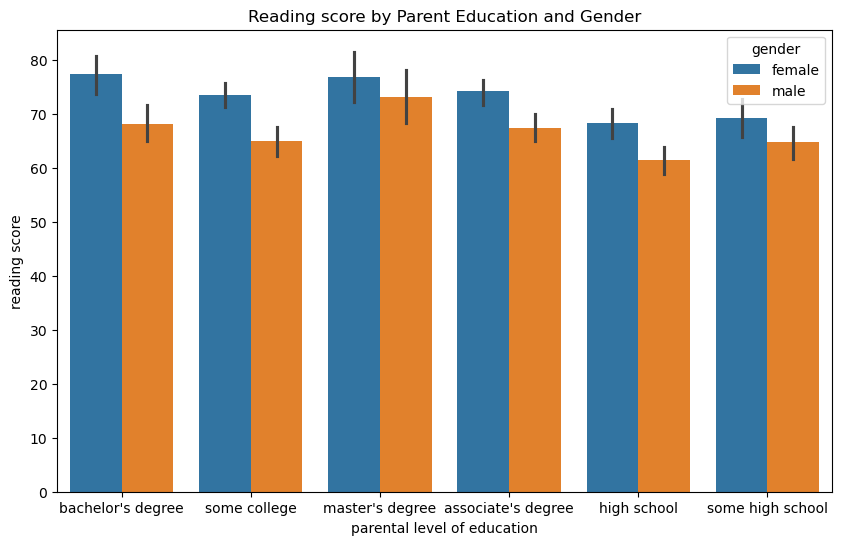

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='parental level of education', y='reading score', hue='gender')
plt.title('Reading score by Parent Education and Gender')
plt.show()

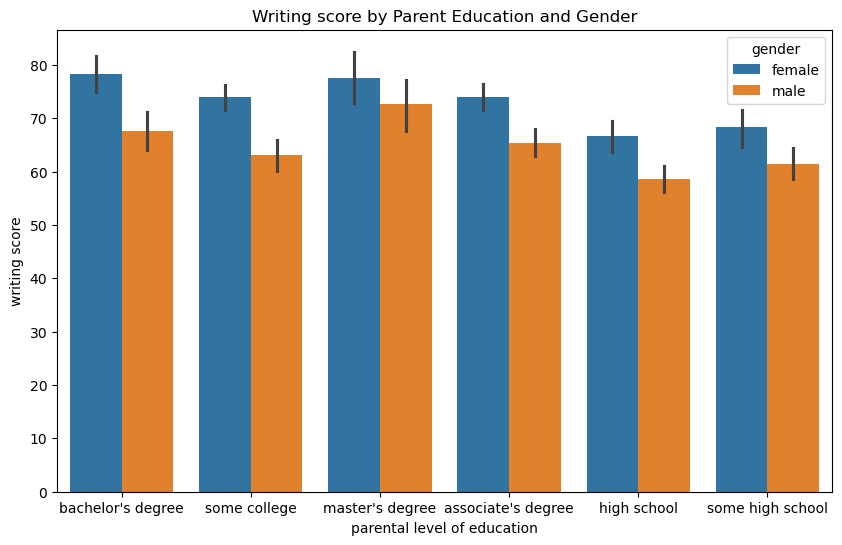

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='parental level of education', y='writing score', hue='gender')
plt.title('Writing score by Parent Education and Gender')
plt.show()

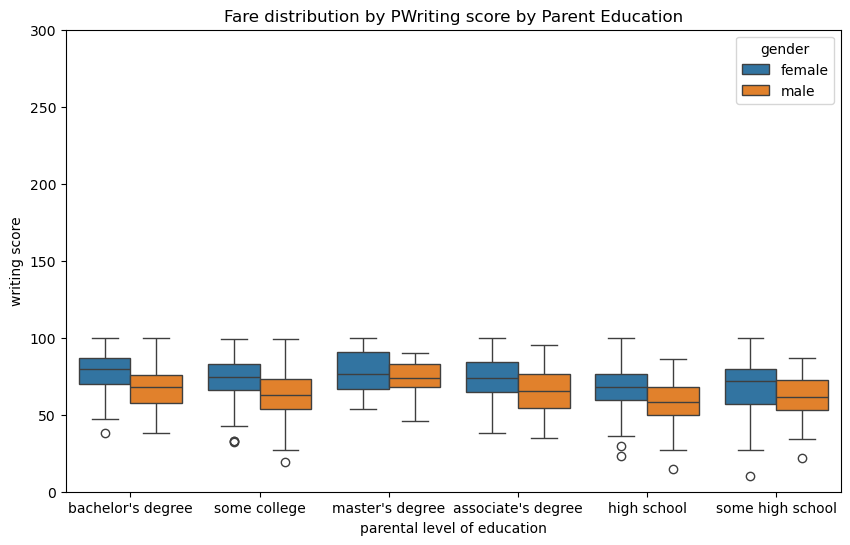

In [27]:
# perhaps your most important plot is boxplot! Take any numerical attribute and plot it along your class
# what do we see in a boxplot?

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='parental level of education', y='writing score', hue='gender')
plt.ylim(0, 300)  # Limiting y-axis to 300 for better visualization
plt.title('Fare distribution by PWriting score by Parent Education')
plt.show()

In [31]:
# https://www.geeksforgeeks.org/blogs/anomaly-detection-techniques/
from numpy import percentile, where, unique

Q1 = percentile(df['writing score'], 25, axis=0)
Q3 = percentile(df['writing score'], 75, axis=0)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomalies = where((df['writing score'] < lower_bound) | (df['writing score'] > upper_bound))
unique_anomalies = unique(anomalies[0])
print("Anomalies detected at indices (IQR):", unique_anomalies)

Anomalies detected at indices (IQR): [ 59  76 327 596 980]


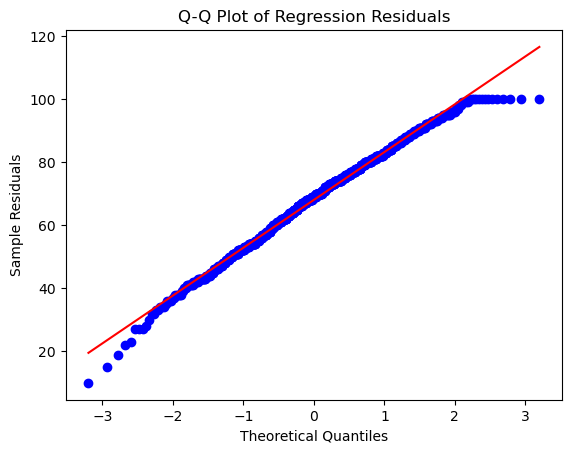

In [36]:
# Sanity check: Q-Q plot to check if errors are normally distributed

stats.probplot(df['writing score'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot of Regression Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Residuals")
plt.show()

In [38]:
# quick data aggregations using "groupby"

df.groupby('gender')['writing score'].mean()

gender
female    72.467181
male      63.311203
Name: writing score, dtype: float64

In [43]:
# data preparation for classification (using "gender" as target variable)

from sklearn import preprocessing

X = df.drop(['gender', 'writing score'], axis=1)
y = df['gender']

pipeline = Pipeline([
    ('encode', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),   # encoding categorical attributes
    ('scaler', preprocessing.RobustScaler()), # minmaxscaler(), standardscaler(), PowerTransformer(), QuantileTransformer(), RobustScaler()
    ('classifier', ensemble.GradientBoostingClassifier(n_estimators=10)) # small number of estimators
])

scores = cross_val_score(pipeline, X, y, cv=10, n_jobs=-1, scoring='f1_macro')  # f1_macro for imbalanced classes
print("Classification accuracy values using 10-fold CV:", scores)   # any negative or extreme values?
print("Mean classification accuracy: %.4f" % scores.mean())

Classification accuracy values using 10-fold CV: [0.42827443 0.45436508 0.42956349 0.39851398 0.37629938 0.3743099
 0.47245737 0.37996032 0.40910671 0.44159544]
Mean classification accuracy: 0.4164


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   negative_outlier_factor      1000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


In [45]:
# Let's see what permutation importance says (another feature selection approach)
# code from https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html

# There's no need to impute values if we use this feature selection approach

pipeline.fit(X, y)
result = permutation_importance(
    pipeline, X, y, n_repeats=10, n_jobs=-1
)

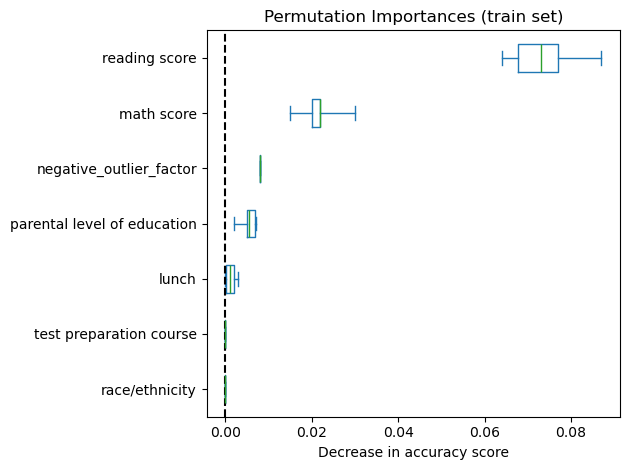

In [46]:
sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (train set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()